<a href="https://colab.research.google.com/github/Naveen-gale/deep_learning/blob/main/languge_detection_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

import joblib

In [50]:
df = pd.read_csv("dataset.csv")

In [51]:
df.head()

,Text,language
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian
1,sebes joseph pereira thomas på eng the jesuit...,Swedish
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,Thai
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,Tamil
4,de spons behoort tot het geslacht haliclona en...,Dutch


In [52]:
df.isnull().sum()

,0
Text,0
language,0


In [53]:
df.duplicated().sum()

np.int64(141)

In [54]:
df.shape

(22000, 2)

In [55]:
df.drop_duplicates(
    inplace=True
)


In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df['language'].unique()

array(['Estonian', 'Swedish', 'Thai', 'Tamil', 'Dutch', 'Japanese',
       'Turkish', 'Latin', 'Urdu', 'Indonesian', 'Portugese', 'French',
       'Chinese', 'Korean', 'Hindi', 'Spanish', 'Pushto', 'Persian',
       'Romanian', 'Russian', 'English', 'Arabic'], dtype=object)

In [58]:
 df['language'].nunique()

22

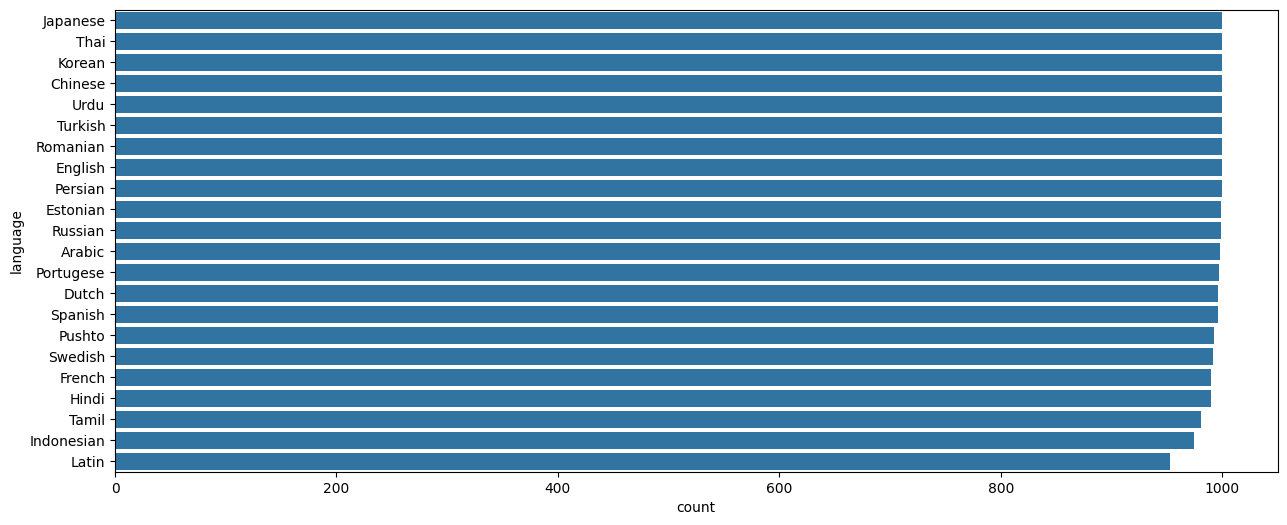

In [59]:
plt.figure(figsize=(15,6))

sns.countplot(
    y=df["language"],
    order=df["language"].value_counts().index
)

plt.show()

In [60]:
df["text_length"] = df["Text"].apply(len)

In [61]:
df.head()

,Text,language,text_length
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian,339
1,sebes joseph pereira thomas på eng the jesuit...,Swedish,171
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,Thai,251
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,Tamil,305
4,de spons behoort tot het geslacht haliclona en...,Dutch,176


In [62]:
df["text_length"].describe()

,text_length
count,21859.000000
mean,356.766321
std,238.835174
min,8.000000
25%,188.000000
50%,275.000000
75%,442.000000
max,1341.000000


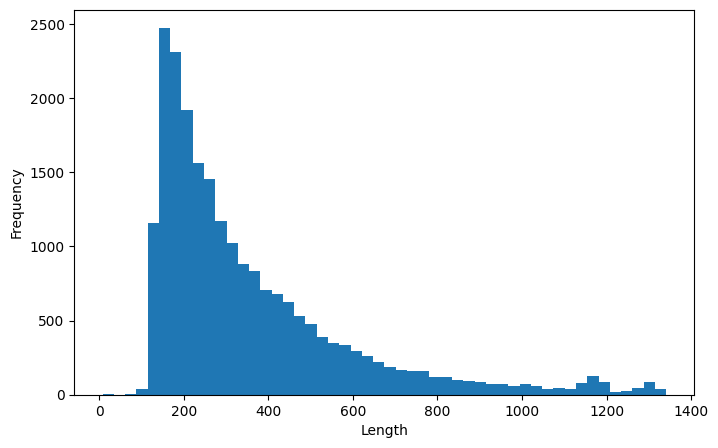

In [63]:
plt.figure(figsize=(8,5))

plt.hist(df["text_length"],bins=50)

plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

In [64]:
encoder = LabelEncoder()
df['Label']= encoder.fit_transform(df['language'])

In [65]:
df.head()

,Text,language,text_length,Label
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian,339,4
1,sebes joseph pereira thomas på eng the jesuit...,Swedish,171,17
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,Thai,251,19
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,Tamil,305,18
4,de spons behoort tot het geslacht haliclona en...,Dutch,176,2


In [66]:
X= df['Text']
y=df['Label']

In [67]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [68]:
max_words= 50000

In [151]:
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def clean_text_final(text):
    text = str(text).lower()
    # Simplified regex: keep only characters from supported scripts and spaces
    # This covers Latin, Devanagari (Hindi), Kannada, Tamil, Thai, and CJK
    text = re.sub(r'[^a-z\u0900-\u097F\u0C80-\u0CFF\u0B80-\u0BFF\u0E00-\u0E7F\u3040-\u30FF\u4E00-\u9FFF]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Character-Level Tokenizer
tokenize = Tokenizer(char_level=True, oov_token="<OOV>")
cleaned_train = [clean_text_final(t) for t in X_train]
tokenize.fit_on_texts(cleaned_train)

# Prepare sequences
X_train_pad = pad_sequences(tokenize.texts_to_sequences(cleaned_train), maxlen=400, padding='pre')
X_test_pad = pad_sequences(tokenize.texts_to_sequences([clean_text_final(t) for t in X_test]), maxlen=400, padding='pre')

print(f"Tokenizer vocabulary size: {len(tokenize.word_index)}")

Tokenizer vocabulary size: 4864


In [139]:
# Cell removed to prevent tokenizer corruption

In [140]:
# Cell removed to prevent sequence mismatch

In [72]:
max_length = 400 # Increased length because characters are more numerous than words

In [141]:
# Cell removed to prevent padding mismatch

In [152]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, BatchNormalization, SpatialDropout1D, Input, Dense, Dropout, Embedding
from tensorflow.keras.models import Sequential

# Increasing model capacity for better feature extraction
model = Sequential([
    Input(shape=(400,)),
    Embedding(input_dim=len(tokenize.word_index) + 1, output_dim=128),
    SpatialDropout1D(0.3),

    Conv1D(512, 7, activation='relu', padding='same'),
    BatchNormalization(),
    Conv1D(256, 5, activation='relu', padding='same'),
    BatchNormalization(),
    Conv1D(128, 3, activation='relu', padding='same'),
    GlobalMaxPooling1D(),

    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(len(encoder.classes_), activation='softmax')
])

In [119]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Adding a scheduler for finer tuning
def scheduler(epoch, lr):
    if epoch < 5:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

lr_callback = tf.keras.callbacks.LearningRateScheduler(scheduler)
print("Model re-compiled with expanded vocabulary and scheduler.")

Model re-compiled with expanded vocabulary and scheduler.


In [76]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [77]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

In [153]:
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights to help with misclassified/minority languages
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_callback]
)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.4812 - loss: 1.4955 - val_accuracy: 0.6695 - val_loss: 0.9695 - learning_rate: 0.0010
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.7185 - loss: 0.7538 - val_accuracy: 0.7557 - val_loss: 0.6445 - learning_rate: 0.0010
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.7470 - loss: 0.6558 - val_accuracy: 0.7541 - val_loss: 0.6394 - learning_rate: 0.0010


In [79]:
loss, accuracy_score = model.evaluate(X_test_pad, y_test)

137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8106 - loss: 0.5473


In [80]:
pred = model.predict(X_test_pad)

137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


In [81]:
pred

array([[1.8706293e-06, 9.9991131e-01, 4.9930854e-08, ..., 3.2403253e-07,
        6.7122401e-09, 5.1275361e-08],
       [1.3172872e-08, 4.0694777e-06, 3.8404480e-04, ..., 4.9093705e-05,
        3.0484433e-05, 2.9531589e-07],
       [4.3285395e-06, 1.1998904e-04, 3.0572575e-03, ..., 8.3512765e-05,
        2.0676665e-04, 2.0292304e-05],
       ...,
       [1.9779787e-08, 1.7059898e-06, 3.3039669e-06, ..., 2.7138643e-07,
        5.7642261e-08, 2.9844965e-05],
       [2.4075111e-06, 2.9431915e-08, 1.4176860e-06, ..., 4.9843158e-07,
        1.7336257e-04, 9.9907756e-01],
       [4.9205904e-04, 7.5561907e-08, 1.2199332e-06, ..., 1.3149113e-06,
        2.2428237e-07, 2.1888954e-03]], dtype=float32)

In [82]:
print(
    classification_report(
        y_test,
        pred.argmax(axis=1)
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       0.99      0.99      0.99       200
           2       0.54      0.56      0.55       199
           3       0.54      0.71      0.62       200
           4       0.67      0.47      0.55       200
           5       0.80      0.95      0.87       198
           6       1.00      0.96      0.98       198
           7       0.61      0.79      0.69       195
           8       1.00      0.99      0.99       200
           9       1.00      0.99      0.99       200
          10       0.44      0.16      0.24       191
          11       0.99      0.99      0.99       200
          12       0.43      0.79      0.56       199
          13       1.00      0.90      0.95       199
          14       0.62      0.45      0.52       200
          15       0.99      0.97      0.98       200
          16       0.50      0.42      0.46       199
          17       0.91    

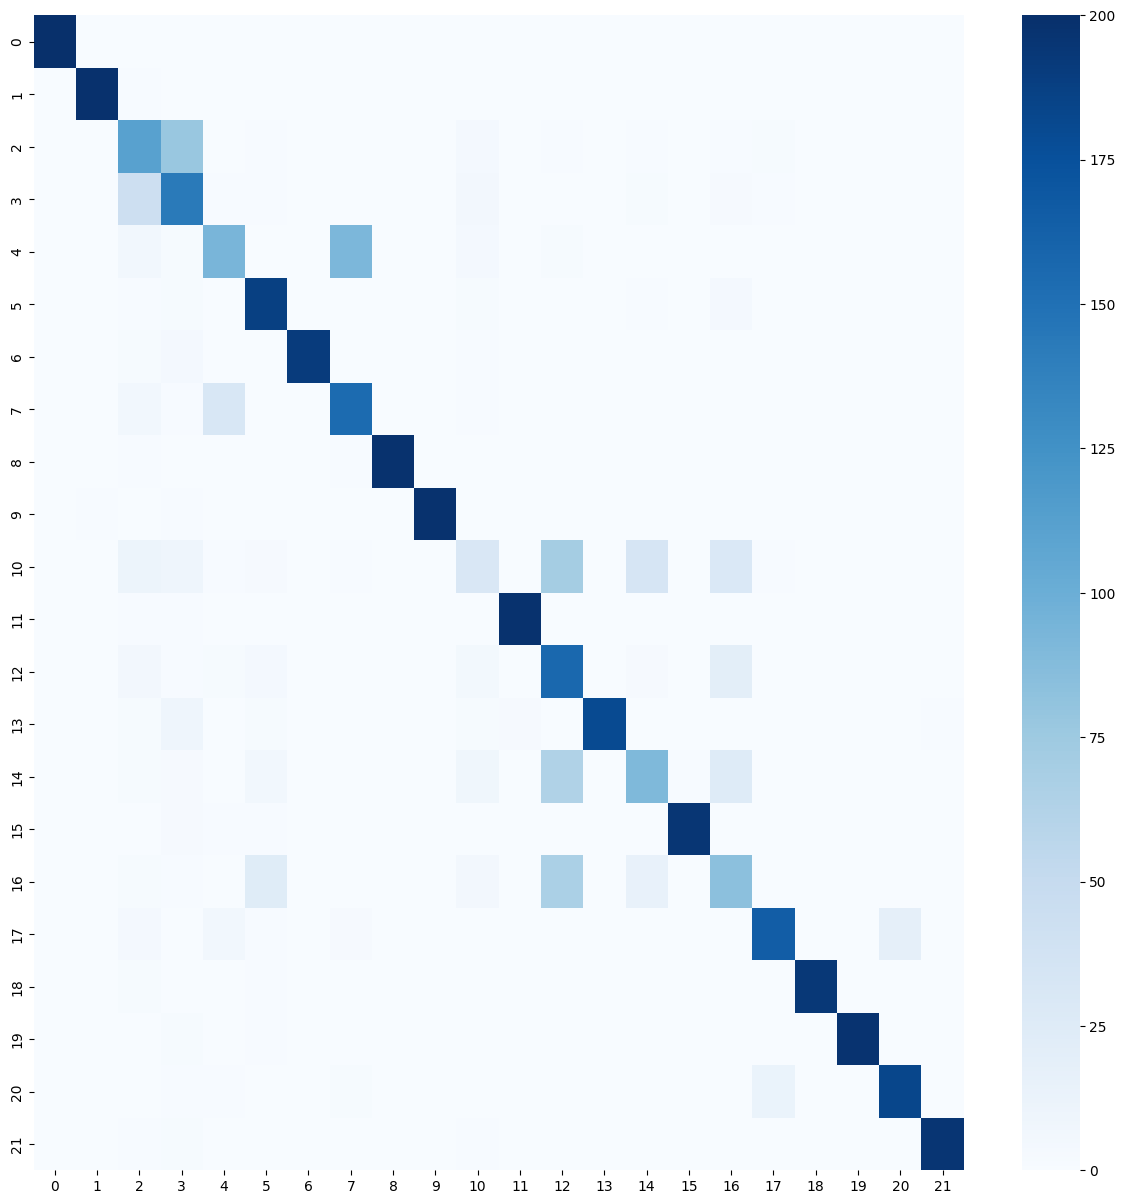

In [83]:
cm = confusion_matrix(y_test,pred.argmax(axis=1))

plt.figure(figsize=(15,15))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues"
)

plt.show()

In [84]:
model.save("language_model.keras")


In [85]:
joblib.dump(
    tokenize,
    "tokenizer.pkl"
)

['tokenizer.pkl']

In [154]:
import numpy as np

def predict_language(sentence):
    cleaned = clean_text_final(sentence)
    seq = tokenize.texts_to_sequences([cleaned])

    if not seq[0]:
        return "Unknown", 0.0

    pad = pad_sequences(seq, maxlen=400, padding='pre')
    probs = model.predict(pad, verbose=0)
    idx = np.argmax(probs)
    conf = np.max(probs)

    return encoder.inverse_transform([idx])[0], conf

final_tests = [
    "Hello my name is Naveen",
    "ನಮಸ್ಕಾರ",
    "This is definitely English",
    "De spons behoort tot het"
]

print("--- Final Verification Results ---")
for text in final_tests:
    lang, conf = predict_language(text)
    print(f"'{text}' -> {lang} ({conf*100:.2f}%)")

--- Final Verification Results ---
'Hello my name is Naveen' -> Korean (26.87%)
'ನಮಸ್ಕಾರ' -> Korean (24.41%)
'This is definitely English' -> Pushto (20.27%)
'De spons behoort tot het' -> Pushto (28.08%)


In [135]:
predict_language("Hello my name is Naveen")

('Pushto', np.float32(0.17564762))

In [136]:
predict_language("ನಮಸ್ಕಾರ")

('Japanese', np.float32(0.39241567))